<a href="https://colab.research.google.com/github/BillPapakyriakou/DataMining-Notebooks/blob/main/assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Τρίτη Σειρά Ασκήσεων
---
### 5324 - Παπακυριακού Βασίλειος


---
##**Ερώτηση 1**


##1.
### **Απόδειξη**:

$$
p_v^T = (1-a)p_v^T P + a v^T
$$

Aπό διαφάνεια 47 (datamining-LAR.pdf),
λύνοντας ως προς $p_v$ έχουμε:

$$
p_v^T = a v^T \left(I - (1-a)P\right)^{-1}
$$

Αντικαθιστούμε στη σχέση  $p_v^T = v^T Q$:

$$
a v^T \left(I - (1-a)P\right)^{-1} = v^T Q
$$

Λύνουμε ως πρός Q:

$$
\boxed{
Q = a \left(I - (1-a)P\right)^{-1}
}
$$

##2.
### **Απόδειξη**:

Έχουμε τη σχέση:  

$$
p_v^T = v^T Q
$$

Για το personalized PageRank έχουμε jump vector:

$$
v^T = (0,\ldots,0,1,0,\ldots,0).
$$

Άρα:

$$
p_i^T = (0,\ldots,0,1,0,\ldots,0)\, Q,
$$

που είναι η i-οστή γραμμή του $Q$.

$$
\fbox{Άρα η i-οστή γραμμή του $Q$ είναι το personalized PageRank διάνυσμα $p_i^T$.}
$$




##3.
### **Απόδειξη**:

Έχουμε το ομοιόμορφο jump vector:

$$
u^T = \left(\frac{1}{n}, \frac{1}{n}, \ldots, \frac{1}{n}\right).
$$

Από τη σχέση $ p_u^T = u^T Q $ :

$$
p_u^T = \left(\frac{1}{n}, \frac{1}{n}, \ldots, \frac{1}{n}\right) Q.
$$

Αυτό αναπαριστά τον μέσο όρο των γραμμών του $Q$.

Από το ερώτημα 2, δείξαμε ότι οι γραμμές του $Q$ είναι τα personalized PageRank διανύσματα $p_i^T$, άρα έχουμε:

$$
p_u^T = \frac{1}{n} \sum_{i=1}^n p_i^T.
$$

Σε μορφή στηλών, γράφεται ως:

$$
\boxed{
p_u = \frac{1}{n} \sum_{i=1}^n p_i.
}
$$


##4.
### **Απόδειξη**:

Θεωρούμε ένα οποιοδήποτε jump vector

$$
v = (v(1), v(2), v(3), \ldots, v(n)),
$$

με $v(i) \ge 0$ και $\sum_{i=1}^n v(i) = 1.$

Από τη σχέση $p_v^T = v^T Q$ έχουμε:

$$
p_v^T = (v(1), v(2), v(3), \ldots, v(n))\, Q
$$

Που είναι γραμμικός συνδυασμός των γραμμών του $Q$ με συντελεστές $v(i)$:

$$
p_v^T = \sum_{i=1}^n v(i)\, (\text{$i$-οστή γραμμή του } Q).
$$

Από το ερώτημα 2, η $i$-οστή γραμμή του $Q$ είναι το personalized PageRank διάνυσμα $p_i^T$, άρα.

$$
p_v^T = \sum_{i=1}^n v(i)\, p_i^T.
$$

Σε μορφή στηλών γράφεται ως:
$$
\boxed{
p_v = \sum_{i=1}^n v(i)\, p_i.
}
$$

---
##**Ερώτηση 2**


### Προετοιμασία δεδομένων

In [2]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# φόρτωση δεδομένων
ratings = pd.read_csv("ratings_small.csv", low_memory=False)
links = pd.read_csv("links_small.csv", low_memory=False)
movies = pd.read_csv("movies_metadata.csv", low_memory=False)

# data cleaning - βγάζουμε NaN, κρατάμε μόνο valid Ids (int)

links["tmdbId"] = pd.to_numeric(links["tmdbId"], errors="coerce")
movies["id"] = pd.to_numeric(movies["id"], errors="coerce")

links = links.dropna(subset=["tmdbId"])
movies = movies.dropna(subset=["id"])

links["tmdbId"] = links["tmdbId"].astype(int)
movies["id"] = movies["id"].astype(int)


# κάνουμε join τα ratings με τα links και τα movies
dataframe = ratings.merge(links, on="movieId", how="inner")
dataframe = dataframe.merge(
    movies[["id", "title"]],
    left_on="tmdbId",
    right_on="id",
    how="inner"
)

# κρατάμε userId, movieId και το rating του user για την ταινία
dataframe = dataframe[["userId", "id", "rating"]]


counts = dataframe.groupby("id").size()  # μετράμε τον αριθμό ratings ανά ταινία
valid_movies = counts[counts >= 10].index  # κρατάμε τα ids που έχουν τουλάχιστον 10 ratings
dataframe = dataframe[dataframe["id"].isin(valid_movies)]  # αφήνουμε μόνο τις ταινίες με >=10 ratings στα δεδομένα

# factorize για να φτιαχτεί σωστά ο sparse πίνακας - δουλεύει με indices 0...n και όχι με ids, αν δεν το κάνουμε
#                                                                             ο πίνακας θα βγεί πολύ μεγαλύτερος
# πχ ids = pd.Series([349, 999, 349, 1010])
# codes, uniques = pd.factorize
# codes = [0, 1, 0, 2], uniques = [349, 999, 1010]

# sort για να παίρνουμε κάθε φορά τα ίδια mappings
movie_codes, movie_ids = pd.factorize(dataframe["id"], sort=True)
user_codes, user_ids = pd.factorize(dataframe["userId"], sort=True)

# δημιουργούμε αραιό πίνακα (ταινίες-χρήστες-ratings)
R = csr_matrix(
    (dataframe["rating"].to_numpy(np.float32), (movie_codes, user_codes)),
    shape=(len(movie_ids), len(user_ids))
)

print("R shape:", R.shape)


R shape: (2242, 671)


### Εφαρμογή K-Means στα δεδομένα (δοκιμή για καλύτερο k)

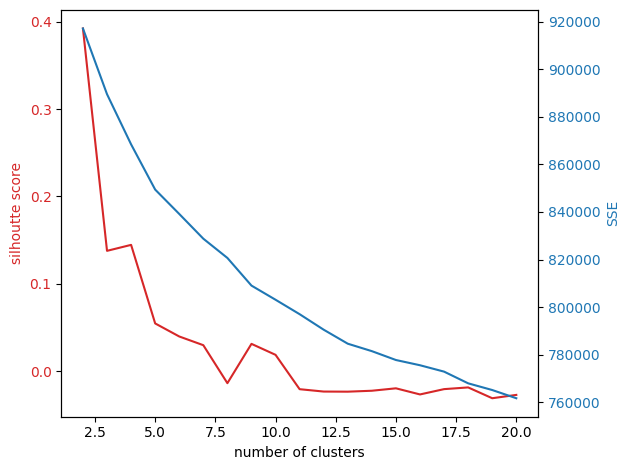

In [3]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt

# το silhouette score απαιτεί dense matrix γι αυτό κάνουμε μετατροπή του sparse
X = R.toarray()

k_values = range(2, 21)  # τιμές από 2 εώς 20
sse = []  # array με τα sum of square errors
sil = []  # array με τα silhouette scores

for k in k_values:
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=5, random_state=35)
    labels = kmeans.fit_predict(R)           # k-means στον sparse πίνακα R
    sse.append(kmeans.inertia_)              # SSE
    sil.append(silhouette_score(X, labels))  # silhouette στον dense πίνακα X

# plots - silhouette score vs sse

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('number of clusters')
ax1.set_ylabel('silhoutte score', color=color)
ax1.plot(list(k_values), sil, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('SSE', color=color)  # we already handled the x-label with ax1
ax2.plot(list(k_values), sse, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()

### Επιλογή καταλληλότερου k και αιτιολόγηση

Μια καλή μέθοδος αξιολόγησης για την εύρεση του καλύτερου k είναι η χρήση του Silhouette Score. Εύκολα παρατηρούμε από το διάγραμμα ότι η καλύτερη τιμή αντιστοιχεί στο k=2, παρόλα αυτά το να έχουμε δύο ομάδες αποτελεί ιδιαίτερα απλή μορφή clustering. Για την τιμή k=4 έχουμε τοπικό μέγιστο για το silhouette score και παράλληλα είμαστε κοντά σε σημείο που παρατηρείτε σιγά σιγά ομαλοποίηση στην τιμή του sse (elbow). Για τους παραπάνω λόγους επιλέγουμε k=4 ως την καταλληλότερη τιμή.

### Εφαρμογή Agglomerative Clustering στα δεδομένα

In [4]:
# χρησιμοποιούμε αριθμό clusters 4 που καταλήξαμε πάνω
best_k = 4

agglo = AgglomerativeClustering(linkage = "complete", n_clusters = best_k)
agglo_labels = agglo.fit_predict(X)

print("\nAgglomerative Clustering (complete)")
print("k =", best_k)
print("Silhouette Score =", silhouette_score(X, agglo_labels))


Agglomerative Clustering (complete)
k = 4
Silhouette Score = 0.5207339


### Εφαρμογή K-Means (με k=4) στα δεδομένα

In [5]:
kmeans = KMeans(init='k-means++', n_clusters=best_k, n_init=10, random_state=35)
kmeans_labels = kmeans.fit_predict(R)

print("\nK-Means")
print("k =", best_k)
print("Silhouette Score =", silhouette_score(X, kmeans_labels))


K-Means
k = 4
Silhouette Score = 0.14450648


### Αξιολόγηση των clusters

In [6]:
import ast


def top3_lift_for_labels(movie_ids, labels, movies):

  # dataframe με movie_ids και σε ποιο cluster ανήκει η καθεμία
  cluster_dataframe = pd.DataFrame({
      "tmdbId": movie_ids,
      "cluster": labels
  })

  # κάνουμε join για να πάρουμε και το genre της ταινίας και τον τίτλο της
  cluster_dataframe = cluster_dataframe.merge(
      movies[["id", "title", "genres"]],
      left_on="tmdbId",
      right_on="id",
      how="left"
  )

  # κρατάμε μια λίστα από genres για κάθε ταινία
  def parse_genres(g):
      if pd.isna(g):
          return []
      try:
          return [d["name"] for d in ast.literal_eval(g)]
      except Exception:
          return []

  # καινούρια στήλη genre_list στο dataframe
  cluster_dataframe["genre_list"] = cluster_dataframe["genres"].apply(parse_genres)

  # σπάει τα genres σε γραμμές για να μπορούμε να τα μετρήσουμε στη συνέχεια
  genre_dataframe = cluster_dataframe[["tmdbId", "cluster", "title", "genre_list"]].explode("genre_list")
  # αφαιρούμε ταινίες χωρίς genre και κάνουμε rename τη στήλη genre_list σε genre αφού κάθε γραμμή έχει πλέον 1 genre
  genre_dataframe = genre_dataframe.dropna(subset=["genre_list"]).rename(columns={"genre_list": "genre"})


  genre_dataframe = genre_dataframe.drop_duplicates(subset=["tmdbId", "genre"])

  # μετράει πόσα movies είναι σε κάθε cluster
  cluster_sizes = cluster_dataframe.groupby("cluster").size().rename("cluster_movies")

  # μετράει πόσες ταινίες σε ένα cluster έχουν ένα genre (πχ στο cluster 2 έχει 200 ταινίες Action)
  cluster_genre_counts = genre_dataframe.groupby(["cluster", "genre"]).size().rename("count_in_cluster").reset_index()

  cluster_genre_counts = cluster_genre_counts.merge(
      cluster_sizes.reset_index(),
      on="cluster",
      how="left"
  )

  # ποσοστό ταινιών που είναι ένα συγκεκριμένο genre
  cluster_genre_counts["freq_in_cluster"] = (
      cluster_genre_counts["count_in_cluster"] / cluster_genre_counts["cluster_movies"]
  )


  total_movies = len(cluster_dataframe)

  global_counts = genre_dataframe.groupby("genre").size().rename("count_global").reset_index()
  # μετράει τη συχνότητα ενός genre σε όλο το dataframe
  global_counts["freq_global"] = global_counts["count_global"] / total_movies


  res = cluster_genre_counts.merge(global_counts[["genre", "freq_global"]], on="genre", how="left")
  res["lift"] = res["freq_in_cluster"] / res["freq_global"]

  # top-3 genres με μεγαλύτερο lift για κάθε cluster
  top3 = (
      res.sort_values(["cluster", "lift"], ascending=[True, False])
        .groupby("cluster")
        .head(3)
        .reset_index(drop=True)
  )

  print(top3[["cluster", "genre", "count_in_cluster", "freq_in_cluster", "freq_global", "lift"]])

  print("--------------------------------------------------")
  print("--------------------------------------------------")

  print("Top-5 genres overall:")
  print(genre_dataframe["genre"].value_counts().head(5))
  print("--------------------------------------------------")

  for c in sorted(genre_dataframe["cluster"].unique()):
      print(f"Cluster {c} top-5 genres:")
      print(genre_dataframe[genre_dataframe["cluster"] == c]["genre"].value_counts().head(5))
      print("--------------------------------------------------")

  print("--------------------------------------------------------------------------------------")


print("K-means top-3 lift:")
top3_lift_for_labels(movie_ids, kmeans_labels, movies)

print("\nAgglomerative top-3 lift:")
top3_lift_for_labels(movie_ids, agglo_labels, movies)


K-means top-3 lift:
    cluster            genre  count_in_cluster  freq_in_cluster  freq_global  \
0         0          Fantasy                29         0.193333     0.118093   
1         0        Adventure                49         0.326667     0.208556   
2         0  Science Fiction                32         0.213333     0.143939   
3         1           Horror               126         0.079747     0.067291   
4         1      Documentary                23         0.014557     0.012478   
5         1  Science Fiction               250         0.158228     0.143939   
6         2              War                26         0.056156     0.034314   
7         2          History                32         0.069114     0.042335   
8         2            Music                28         0.060475     0.043672   
9         3           Action                21         0.411765     0.241533   
10        3         Thriller                21         0.411765     0.258021   
11        3         

### Σχολιασμός των clusters

Με μια πρώτη ματιά, κοιτώντας τα Silhouette Scores των δύο αλγορίθμων βλέπουμε ότι ο Agglomerative πετυχαίνει πολύ καλύτερη τιμή από τον K-Means. Αυτό μας δείχνει ότι τα clusters του πρώτου είναι πιο απομακρυσμένα μεταξύ τους και έχουν καλύτερη εσωτερική συνοχή. Κοιτώντας όμως τα ίδια τα clusters όμως παρατηρούμε ότι ο Agglomerative έχει δημιουργήσει 3 πολύ μικρά clusters και ένα ιδιαίτερα μεγάλο, δείχνοντας ότι η ομαδοποίηση δεν ήταν και πολύ χρήσιμη.

Αν προσπαθήσουμε να αξιολογήσουμε τα clusters με βάση τη συχνότητα εμφάνισης των genres, βλέπουμε ότι τα πιό συχνά genres σε κάθε cluster είναι και τα πιο δημοφιλή σε όλα μας τα δεδομένα, π.χ. Drama, Comedy, με αποτέλεσμα να μην βγάζουμε καλά συμπεράσματα για το label του κάθε cluster. Συγκρκριμένα βλέπουμε ότι σε κάθε cluster, το πιο συχνό genre είναι το Drama, που είναι και το πιο συχνό στο Dataset.

Αν χρησιμοποιοήσουμε το lift για την αξιολόγηση, και συγκεκριμένα τα 3 genres με το μεγαλύτερο lift σε κάθε genre μπορούμε να έχουμε μια πιο ξεκάθαρη εικόνα.

Εξετάζοντας τον K-Means, βλέπουμε ότι στο 1ο cluster έχουμε ταινίες Fantasy, Adventure, Science Fiction που είναι οι ταινίες επιστημονικής φαντασίας και δράσης. Στο δεύτερο έχουμε έμφαση στις ταινίες τρόμου και ντοκιμαντέρ, στο τρίτο έχουμε ιστορικές - ταινίες πολέμου και στο τέταρτο έχουμε ταινίες θρίλερ - μυστηρίου. Αν και το clustering έγινε με βάση τα ratings, παρατηρούμε ότι οι χρήστες τείνουν να βαθμολογούν παρόμοια ταινίες παρόμοιων ειδών.

Η ερμηνεία των clusters για τον Agglomerative αλγόριθμο είναι πιο δύσκολη καθώς έχουμε ένα πολύ μεγάλο cluster και τα υπόλοιπα που είναι πολύ μικρά. Παρατηρούμε μερικές πολύ υψηλές τιμές σε lift οι οποίες όμως οφείλονται στο μικρό πλήθος ταινίων στο αντίστοιχο cluster. Από την άλλη το μεγάλο cluster είναι επίσης δύσκολο στην ερμηνεία καθώς περιλαμβάνει πολλές ταινίες από πολλά διαφορετικά είδη.

### Εφαρμογή PCA στον πίνακα με τα ratings

In [9]:
from sklearn.decomposition import PCA


# Για να κάνουμε PCA μετατρέπουμε το R σε dense array
X1 = R.toarray()

#  PCA με 50 πιο ισχυρά χαρακτηριστικά (latent factors)
pca = PCA(n_components=50, random_state=35)
X_pca = pca.fit_transform(X1)

print("X shape:", X1.shape)
print("X_pca shape:", X_pca.shape)


# K-means με PCA
kmeans_pca = KMeans(init="k-means++", n_clusters=best_k, n_init=10, random_state=35)
kmeans_labels_pca = kmeans_pca.fit_predict(X_pca)

print("\nK-Means w PCA(50)")
print("for k =", best_k)
print("Silhouette Score =", silhouette_score(X_pca, kmeans_labels_pca))

# Agglomerative με PCA
agglo_pca = AgglomerativeClustering(linkage="complete", n_clusters=best_k)
agglo_labels_pca = agglo_pca.fit_predict(X_pca)

print("\nAgglomerative w PCA(50) (complete)")
print("for k =", best_k)
print("Silhouette Score =", silhouette_score(X_pca, agglo_labels_pca))


print("\nK-means + PCA top-3 lift:")
top3_lift_for_labels(movie_ids, kmeans_labels_pca, movies)

print("\nAgglomerative + PCA top-3 lift:")
top3_lift_for_labels(movie_ids, agglo_labels_pca, movies)

X shape: (2242, 671)
X_pca shape: (2242, 50)

K-Means w PCA(50)
for k = 4
Silhouette Score = 0.20701975

Agglomerative w PCA(50) (complete)
for k = 4
Silhouette Score = 0.619301

K-means + PCA top-3 lift:
    cluster            genre  count_in_cluster  freq_in_cluster  freq_global  \
0         0          Fantasy                29         0.193333     0.118093   
1         0        Adventure                49         0.326667     0.208556   
2         0  Science Fiction                32         0.213333     0.143939   
3         1           Horror               127         0.080076     0.067291   
4         1      Documentary                22         0.013871     0.012478   
5         1  Science Fiction               252         0.158890     0.143939   
6         2           Action                22         0.423077     0.241533   
7         2          Mystery                 8         0.153846     0.090018   
8         2         Thriller                22         0.423077     0.25802

### Σχολιασμός των clusters μετά το PCA

Εφαρμόζοντας PCA στα δεδομένα παρατηρούμε γενικά βελτίωση στο clustering. Με τη μείωση των διαστάσεων μειώνεται ο θόρυβος και περιμένουμε να γίνει καλύτερη ομαδοποίηση με πιο ξεκάθαρα clusters.

Αρχικά βλέπουμε αύξηση στο Silhouette Score και των δύο αλγορίθμων. Στον K-Means τα περισσότερα top-3 genres με βάση το lift αυξάνονται, κάνοντας τα λίγο πιο καθαρά. Ωστόσο τα είδη παραμένουν τα ίδια, οπότε δεν αλλάζει κάτι ουσιαστικό στην ερμηνεία τους.

Στον Agglomerative αλγόριθμο εξακολουθούμε να παίρνουμε το μεγάλο cluster και τα υπόλοιπα μικρά με τη διαφορά ότι πλέον μπορούμε να βγάλουμε περισσότερο νόημα για τη θεματική ενότητα των cluster, όπως clusters με ταινίες πολέμου, δράσης και επιστημονικής φαντασίας. Το μεγάλο cluster παραμένει δύσκολο στην ερμηνεία αφού έχει ταινίες από είδη Animation, Documentary και Horror.

Το συμπέρασμα είναι ότι η χρήση του PCA βελτιώνει αισθητά την ποιότητα της ομαδοποίησης, αν και δεν λύνει πλήρως το πρόβλημα του μεγέθους των cluster που συναντάμε στον Agglomerative αλγόριθο.

### Εναλλακτικός τρόπος αξιολόγησης των clusters

Ένας απλός τρόπος για να αξιολογήσουμε τα clusters είναι να πάρουμε τον μέσο όρο των ratings των ταινιών που ανήκουν σε κάθε cluster. Αν δούμε διαφορά του μέσου όρου σε κάθε cluster τότε βλέπουμε ότι η ομαδοποίηση ξεχωρίζει ταινίες με διαφορετικό acceptance level. Για περισσότερη ακρίβεια, θα μπορούσαμε να εισάγουμε και τον αριθμό των βαθμολογιών για κάθε ταινία ώστε να έχουμε μια πιο ξεκάθαρη εικόνα,   π.χ. να δούμε αν μερικά clusters περιλαμβάνουν άγνωστες αλλά καλές ταινίες ή δημοφιλής blockbuster ταινίες.

---
##**Ερώτηση 3**